<a href="https://colab.research.google.com/github/sethmanya001-rgb/part-3-nlp-sequence-modeling-/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import os

uploaded = files.upload()  # upload your zip file

import zipfile
zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall('.')

os.makedirs('results', exist_ok=True)
print("Done! Files:", os.listdir('part_3_nlp_sequence_modeling'))

Saving part_3_nlp_sequence_modeling-20260516T193458Z-3-001.zip to part_3_nlp_sequence_modeling-20260516T193458Z-3-001.zip
Done! Files: ['customer_support_text_classification.csv', 'data_dictionary.md']


In [2]:
!pip install tensorflow scikit-learn matplotlib seaborn nltk pandas numpy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, re
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

np.random.seed(42)
tf.random.set_seed(42)

print("All libraries loaded!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries loaded!


In [3]:
df = pd.read_csv('part_3_nlp_sequence_modeling/customer_support_text_classification.csv')

print("="*50)
print("TASK 1 - DATASET UNDERSTANDING")
print("="*50)
print(f"Total records  : {df.shape[0]}")
print(f"Total columns  : {df.shape[1]}")
print(f"Column names   : {df.columns.tolist()}")
print(f"\nTarget column  : sentiment_label")
print(f"Classes        : {df['sentiment_label'].unique().tolist()}")

TASK 1 - DATASET UNDERSTANDING
Total records  : 1500
Total columns  : 6
Column names   : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Target column  : sentiment_label
Classes        : ['neutral', 'positive', 'negative']


In [4]:
print("SAMPLE TEXT RECORDS:")
print("="*50)
for i in range(3):
    print(f"\nMessage {i+1}: {df['customer_message'].iloc[i]}")
    print(f"Sentiment   : {df['sentiment_label'].iloc[i]}")

SAMPLE TEXT RECORDS:

Message 1: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
Sentiment   : neutral

Message 2: I need information about the payment process.
Sentiment   : neutral

Message 3: The refund process was fast and convenient. I appreciate the quick response.
Sentiment   : positive


Average message length : 12.7 words
Min length             : 7 words
Max length             : 26 words

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


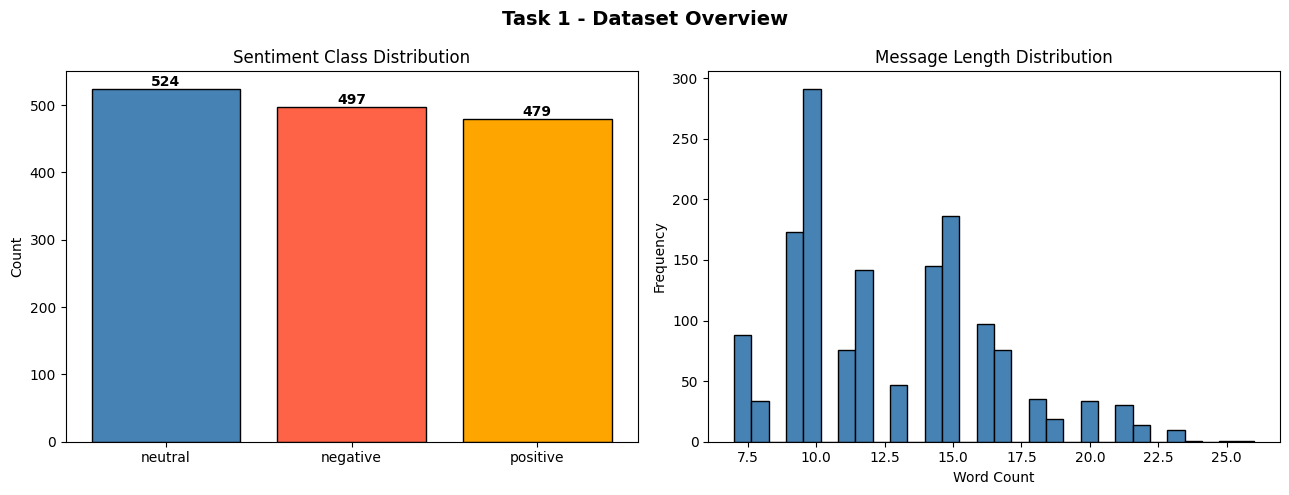

Saved!


In [5]:
print(f"Average message length : {df['word_count'].mean():.1f} words")
print(f"Min length             : {df['word_count'].min()} words")
print(f"Max length             : {df['word_count'].max()} words")

print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Task 1 - Dataset Overview', fontsize=14, fontweight='bold')

counts = df['sentiment_label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['steelblue','tomato','orange'], edgecolor='black')
axes[0].set_title('Sentiment Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

axes[1].hist(df['word_count'], bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Message Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('results/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Step 3: Remove extra spaces
    text = text.strip()
    # Step 4: Tokenize (split into words)
    words = text.split()
    # Step 5: Remove stopwords (like 'the', 'is', 'and')
    words = [w for w in words if w not in stop_words]
    # Step 6: Join back
    return ' '.join(words)

df['cleaned_message'] = df['customer_message'].apply(clean_text)

print("TASK 2 - TEXT PREPROCESSING")
print("="*50)
print("BEFORE cleaning:")
print(df['customer_message'].iloc[0])
print("\nAFTER cleaning:")
print(df['cleaned_message'].iloc[0])
print("\nPreprocessing steps applied:")
print("  ✅ Lowercasing")
print("  ✅ Removed special characters")
print("  ✅ Tokenization")
print("  ✅ Stopword removal")

TASK 2 - TEXT PREPROCESSING
BEFORE cleaning:
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

AFTER cleaning:
need information payment process ticket number please respond soon possible

Preprocessing steps applied:
  ✅ Lowercasing
  ✅ Removed special characters
  ✅ Tokenization
  ✅ Stopword removal


In [7]:
print("TASK 3 - TEXT VECTORIZATION")
print("="*50)
print("""
WHY MUST TEXT BE CONVERTED TO VECTORS?
---------------------------------------
Computers only understand numbers, not words.
We must convert each message into a list of numbers
so the model can do math on it.

Methods used:
1. Bag of Words (BoW): counts how many times each word appears
2. TF-IDF: gives higher score to important/rare words
3. Tokenizer sequences: converts words to integer IDs for deep learning
""")

# Train/test split first
X = df['cleaned_message']
y = df['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

TASK 3 - TEXT VECTORIZATION

WHY MUST TEXT BE CONVERTED TO VECTORS?
---------------------------------------
Computers only understand numbers, not words.
We must convert each message into a list of numbers
so the model can do math on it.

Methods used:
1. Bag of Words (BoW): counts how many times each word appears
2. TF-IDF: gives higher score to important/rare words
3. Tokenizer sequences: converts words to integer IDs for deep learning

Training samples: 1200
Testing samples : 300


In [8]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Bag of Words
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)
print("BoW shape    :", X_train_bow.shape)
print("\nEach message is now a vector of 5000 numbers!")
print("Example: 'payment issue' → [0, 0.3, 0, 0.7, 0, ...]")

TF-IDF shape: (1200, 146)
BoW shape    : (1200, 146)

Each message is now a vector of 5000 numbers!
Example: 'payment issue' → [0, 0.3, 0, 0.7, 0, ...]


In [9]:
print("TASK 4 - BASELINE MODELS")
print("="*50)

# Model 1: Logistic Regression with TF-IDF
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_acc  = accuracy_score(y_test, lr_pred)

print("MODEL 1: Logistic Regression + TF-IDF")
print(f"Accuracy: {lr_acc*100:.2f}%")
print(classification_report(y_test, lr_pred))

TASK 4 - BASELINE MODELS
MODEL 1: Logistic Regression + TF-IDF
Accuracy: 100.00%
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [10]:
# Model 2: Naive Bayes with Bag of Words
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
nb_pred = nb_model.predict(X_test_bow)
nb_acc  = accuracy_score(y_test, nb_pred)

print("MODEL 2: Naive Bayes + Bag of Words")
print(f"Accuracy: {nb_acc*100:.2f}%")
print(classification_report(y_test, nb_pred))

MODEL 2: Naive Bayes + Bag of Words
Accuracy: 100.00%
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



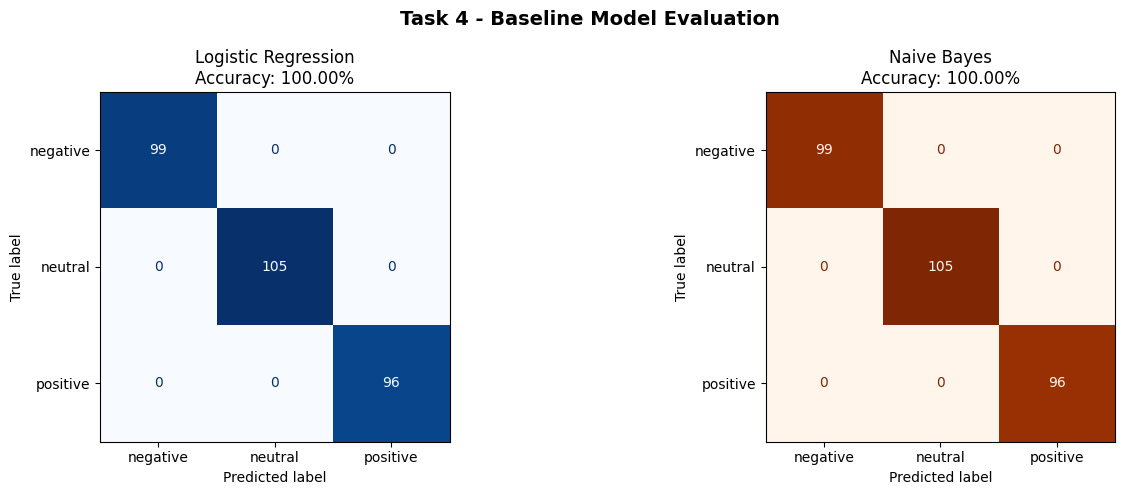

Saved → results/model_evaluation.png


In [11]:
# Use Logistic Regression (usually better)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 4 - Baseline Model Evaluation', fontsize=14, fontweight='bold')

classes = ['negative', 'neutral', 'positive']

cm1 = confusion_matrix(y_test, lr_pred, labels=classes)
ConfusionMatrixDisplay(cm1, display_labels=classes).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_acc*100:.2f}%')

cm2 = confusion_matrix(y_test, nb_pred, labels=classes)
ConfusionMatrixDisplay(cm2, display_labels=classes).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Naive Bayes\nAccuracy: {nb_acc*100:.2f}%')

plt.tight_layout()
plt.savefig('results/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/model_evaluation.png")

In [12]:
baseline_results = pd.DataFrame([
    {'Model': 'Logistic Regression + TF-IDF', 'Accuracy': round(lr_acc*100, 2)},
    {'Model': 'Naive Bayes + Bag of Words',   'Accuracy': round(nb_acc*100, 2)},
])
baseline_results.to_csv('results/model_evaluation.csv', index=False)
print(baseline_results)
print("Saved → results/model_evaluation.csv")

                          Model  Accuracy
0  Logistic Regression + TF-IDF     100.0
1    Naive Bayes + Bag of Words     100.0
Saved → results/model_evaluation.csv


In [13]:
print("TASK 5 - LSTM SEQUENCE MODEL")
print("="*50)

# Convert words to integer sequences
MAX_WORDS = 5000   # vocabulary size
MAX_LEN   = 50     # max words per message

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of numbers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad so all sequences are same length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print("Example message:")
print("Original :", X_train.iloc[0])
print("As numbers:", X_train_seq[0])
print("Padded   :", X_train_pad[0])
print(f"\nAll sequences now have length: {MAX_LEN}")

TASK 5 - LSTM SEQUENCE MODEL
Example message:
Original : confirm whether ticket assigned please respond soon possible
As numbers: [65, 66, 2, 67, 4, 5, 6, 7]
Padded   : [65 66  2 67  4  5  6  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]

All sequences now have length: 50


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

Label encoding:
  negative → 0
  neutral → 1
  positive → 2


In [15]:
lstm_model = keras.Sequential([
    # Embedding: converts word IDs to dense vectors
    layers.Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),

    # LSTM: reads sequence word by word, remembers context
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),

    # Dense hidden layer
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # Output: 3 neurons for 3 sentiment classes
    layers.Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=5,
                            restore_best_weights=True, verbose=1)

print("Training LSTM... please wait!")

history = lstm_model.fit(
    X_train_pad, y_train_enc,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete!")

Training LSTM... please wait!
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.3417 - loss: 1.1002 - val_accuracy: 0.3042 - val_loss: 1.1009
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3229 - loss: 1.0999 - val_accuracy: 0.3042 - val_loss: 1.1018
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3323 - loss: 1.0989 - val_accuracy: 0.3375 - val_loss: 1.1000
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3542 - loss: 1.0983 - val_accuracy: 0.3375 - val_loss: 1.1006
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3365 - loss: 1.0988 - val_accuracy: 0.3042 - val_loss: 1.1006
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3219 - loss: 1.0985 - val_accuracy: 0.3042 - val_loss: 1.1018
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.3490 - loss: 1.0978 - val_accuracy: 0.3042 - val_loss: 1.1021
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.3375 - loss: 1.

In [17]:
loss, acc = lstm_model.evaluate(X_test_pad, y_test_enc, verbose=0)
print(f"LSTM Test Accuracy: {acc*100:.2f}%")
print(f"LSTM Test Loss    : {loss:.4f}")

y_pred_lstm = np.argmax(lstm_model.predict(X_test_pad, verbose=0), axis=1)
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_lstm,
      target_names=le.classes_))

LSTM Test Accuracy: 35.00%
LSTM Test Loss    : 1.0979

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        99
     neutral       0.35      1.00      0.52       105
    positive       0.00      0.00      0.00        96

    accuracy                           0.35       300
   macro avg       0.12      0.33      0.17       300
weighted avg       0.12      0.35      0.18       300



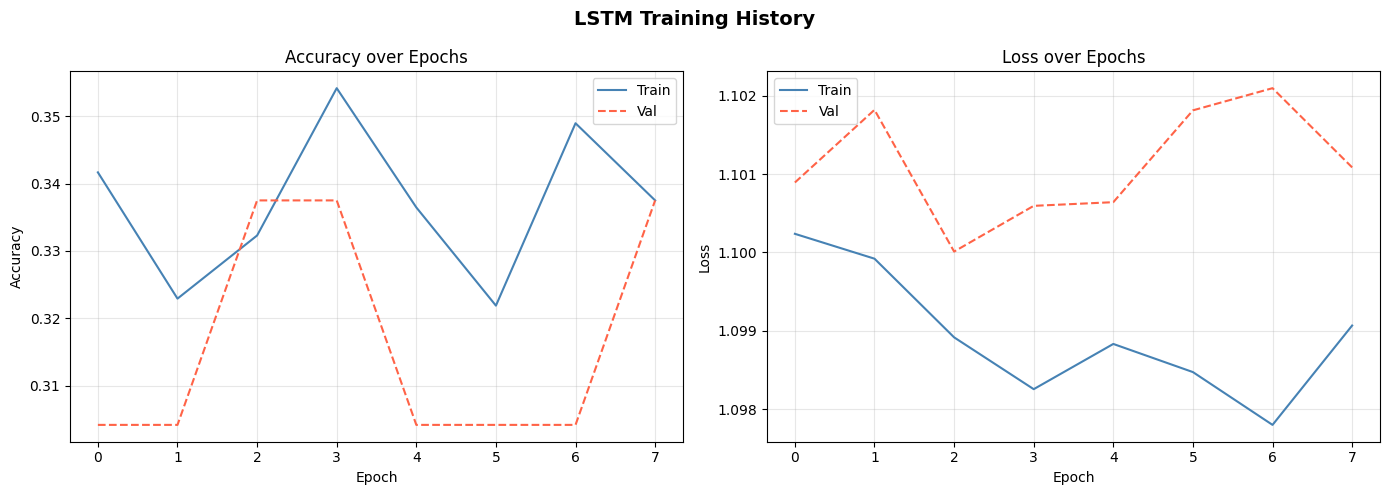

Saved!


In [18]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='tomato', linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='tomato', linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [19]:
sample_messages = [
    "I am very happy with your service!",
    "My order is delayed and nobody is helping me.",
    "I need information about my account."
]

sample_cleaned = [clean_text(m) for m in sample_messages]
sample_seq     = tokenizer.texts_to_sequences(sample_cleaned)
sample_pad     = pad_sequences(sample_seq, maxlen=MAX_LEN, padding='post')
sample_preds   = np.argmax(lstm_model.predict(sample_pad, verbose=0), axis=1)

print("SAMPLE PREDICTIONS:")
print("="*60)
with open('results/sample_predictions.txt', 'w') as f:
    for msg, pred in zip(sample_messages, sample_preds):
        label = le.classes_[pred]
        line = f"Message  : {msg}\nPredicted: {label}\n{'-'*50}"
        print(line)
        f.write(line + '\n')

print("\nSaved → results/sample_predictions.txt")

SAMPLE PREDICTIONS:
Message  : I am very happy with your service!
Predicted: neutral
--------------------------------------------------
Message  : My order is delayed and nobody is helping me.
Predicted: neutral
--------------------------------------------------
Message  : I need information about my account.
Predicted: neutral
--------------------------------------------------

Saved → results/sample_predictions.txt


In [20]:
print("""
TASK 6 - ATTENTION AND TRANSFORMER REFLECTION
===============================================

1. WHY DO RNNs STRUGGLE WITH LONG-TERM DEPENDENCIES?
------------------------------------------------------
RNNs read text word by word from left to right.
They pass a "hidden state" from one word to the next.
Problem: by the time the model reaches word 50,
the information from word 1 has almost disappeared.
This is called the vanishing gradient problem.
Example: "The food at this restaurant which I visited
last Tuesday with my family was terrible."
By the time RNN reads 'terrible', it has almost forgotten
'food' - so it cannot link them properly.

2. HOW DO LSTMs HELP WITH MEMORY?
----------------------------------
LSTM (Long Short-Term Memory) adds special gates:
- Forget Gate : decides what old info to throw away
- Input Gate  : decides what new info to store
- Output Gate : decides what to output
This allows LSTM to remember important info
from much earlier in the sequence.
Example: LSTM can remember 'food' even after
reading 20 more words.

3. WHAT DOES ATTENTION SOLVE?
-------------------------------
Attention allows the model to look at ALL words
at the same time and decide which ones are most
important for the current prediction.
Instead of passing info step by step,
attention directly connects any word to any other word.
Example: when predicting sentiment of 'terrible',
attention directly focuses on 'food' and 'terrible'
regardless of how many words are between them.

4. WHY ARE TRANSFORMERS IMPORTANT IN MODERN NLP?
-------------------------------------------------
Transformers use ONLY attention (no RNN at all).
This makes them:
- Much faster (can process all words in parallel)
- Better at understanding long documents
- Able to be trained on massive datasets
Famous transformer models:
- BERT  : used for text classification, search
- GPT-4 : used for text generation, chatbots
- Claude: used for conversation and reasoning
Without transformers, ChatGPT and Claude would
not exist! They are the foundation of modern
Generative AI.
""")


TASK 6 - ATTENTION AND TRANSFORMER REFLECTION

1. WHY DO RNNs STRUGGLE WITH LONG-TERM DEPENDENCIES?
------------------------------------------------------
RNNs read text word by word from left to right.
They pass a "hidden state" from one word to the next.
Problem: by the time the model reaches word 50,
the information from word 1 has almost disappeared.
This is called the vanishing gradient problem.
Example: "The food at this restaurant which I visited
last Tuesday with my family was terrible."
By the time RNN reads 'terrible', it has almost forgotten
'food' - so it cannot link them properly.

2. HOW DO LSTMs HELP WITH MEMORY?
----------------------------------
LSTM (Long Short-Term Memory) adds special gates:
- Forget Gate : decides what old info to throw away
- Input Gate  : decides what new info to store
- Output Gate : decides what to output
This allows LSTM to remember important info
from much earlier in the sequence.
Example: LSTM can remember 'food' even after
reading 20 more 

In [21]:
from google.colab import files
import zipfile

with zipfile.ZipFile('part3_results.zip', 'w') as z:
    for f in os.listdir('results'):
        z.write(f'results/{f}')

files.download('part3_results.zip')
print("All results downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All results downloaded!


In [22]:
req = """tensorflow>=2.13.0
numpy>=1.24.0
pandas>=2.0.0
scikit-learn>=1.3.0
matplotlib>=3.7.0
seaborn>=0.12.0
nltk>=3.8.0
jupyter>=1.0.0
"""
with open('requirements.txt', 'w') as f:
    f.write(req)

files.download('requirements.txt')
print("requirements.txt downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

requirements.txt downloaded!
